# I extracted the shot data from sofascore

In [3]:
from curl_cffi import requests
from bs4 import BeautifulSoup

url = "https://www.sofascore.com/api/v1/event/15631368/shotmap"

response = requests.get(url)
response.status_code
response.json()

print(response.status_code)
print(response.json())

data = response.json()
print(data.keys())

200
{'shotmap': [{'player': {'name': 'Lewis Hall', 'firstName': 'Lewis Hall', 'slug': 'lewis-hall', 'shortName': 'L. Hall', 'position': 'D', 'jerseyNumber': '3', 'userCount': 4619, 'gender': 'M', 'sofascoreId': 'lewishall_10', 'id': 1136730, 'fieldTranslations': {'nameTranslation': {'ar': 'لويس هال', 'bn': 'লুইস হল', 'hi': 'लुईस हॉल'}, 'shortNameTranslation': {'ar': 'ل. هال', 'bn': 'এল. হল', 'hi': 'एल. हॉल'}}}, 'isHome': False, 'shotType': 'save', 'situation': 'assisted', 'playerCoordinates': {'x': 9.1, 'y': 29.5, 'z': 0}, 'bodyPart': 'right-foot', 'goalMouthLocation': 'low-centre', 'goalMouthCoordinates': {'x': 0, 'y': 51.3, 'z': 7}, 'blockCoordinates': {'x': 1.5, 'y': 46.4, 'z': 0}, 'xg': 0.038754168897867, 'xgot': 0.041082710027695, 'goalkeeper': {'name': 'Wojciech Szczęsny', 'slug': 'wojciech-szczesny', 'shortName': 'W. Szczęsny', 'position': 'G', 'jerseyNumber': '25', 'userCount': 95146, 'gender': 'M', 'id': 50490, 'fieldTranslations': {'nameTranslation': {'ar': 'فويتشيك تشيزني', 

# I converted it into a DataFrame

In [4]:
import pandas as pd

shots = pd.DataFrame(data["shotmap"])

print(shots.head())

                                              player  isHome shotType  \
0  {'name': 'Lewis Hall', 'firstName': 'Lewis Hal...   False     save   
1  {'name': 'Harvey Barnes', 'firstName': '', 'la...   False     miss   
2  {'name': 'Jacob Ramsey', 'slug': 'jacob-ramsey...   False    block   
3  {'name': 'Lamine Yamal', 'slug': 'lamine-yamal...    True     save   
4  {'name': 'Harvey Barnes', 'firstName': '', 'la...   False     save   

            situation               playerCoordinates    bodyPart  \
0            assisted   {'x': 9.1, 'y': 29.5, 'z': 0}  right-foot   
1              corner   {'x': 3.8, 'y': 38.7, 'z': 0}        head   
2  throw-in-set-piece  {'x': 12.6, 'y': 34.3, 'z': 0}  right-foot   
3            assisted  {'x': 18.8, 'y': 76.2, 'z': 0}   left-foot   
4          fast-break    {'x': 21.5, 'y': 34, 'z': 0}  right-foot   

  goalMouthLocation            goalMouthCoordinates  \
0        low-centre     {'x': 0, 'y': 51.3, 'z': 7}   
1              high  {'x': 0, 'y': 5

In [5]:
import pandas as pd

shots_df = pd.DataFrame({
    "player": [s["player"]["name"] for s in data["shotmap"]],
    "team_home": [s["isHome"] for s in data["shotmap"]],
    "shot_type": [s["shotType"] for s in data["shotmap"]],
    "situation": [s["situation"] for s in data["shotmap"]],
    "body_part": [s["bodyPart"] for s in data["shotmap"]],
    "x": [s["playerCoordinates"]["x"] for s in data["shotmap"]],
    "y": [s["playerCoordinates"]["y"] for s in data["shotmap"]],
    "xg": [s["xg"] for s in data["shotmap"]],
    "minute": [s["time"] for s in data["shotmap"]]
})

print(shots_df.head())

          player  team_home shot_type           situation   body_part     x  \
0     Lewis Hall      False      save            assisted  right-foot   9.1   
1  Harvey Barnes      False      miss              corner        head   3.8   
2   Jacob Ramsey      False     block  throw-in-set-piece  right-foot  12.6   
3   Lamine Yamal       True      save            assisted   left-foot  18.8   
4  Harvey Barnes      False      save          fast-break  right-foot  21.5   

      y        xg  minute  
0  29.5  0.038754      90  
1  38.7  0.035868      89  
2  34.3  0.047727      88  
3  76.2  0.028694      86  
4  34.0  0.040069      80  


In [6]:
shots_df.head()

,player,team_home,shot_type,situation,body_part,x,y,xg,minute
0,Lewis Hall,False,save,assisted,right-foot,9.1,29.5,0.038754,90
1,Harvey Barnes,False,miss,corner,head,3.8,38.7,0.035868,89
2,Jacob Ramsey,False,block,throw-in-set-piece,right-foot,12.6,34.3,0.047727,88
3,Lamine Yamal,True,save,assisted,left-foot,18.8,76.2,0.028694,86
4,Harvey Barnes,False,save,fast-break,right-foot,21.5,34.0,0.040069,80


In [32]:
shots_df.to_csv("shots.csv", index=False)
from google.colab import files
files.download("shots.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
shots_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   player     26 non-null     object 
 1   team_home  26 non-null     bool   
 2   shot_type  26 non-null     object 
 3   situation  26 non-null     object 
 4   body_part  26 non-null     object 
 5   x          26 non-null     float64
 6   y          26 non-null     float64
 7   xg         26 non-null     float64
 8   minute     26 non-null     int64  
dtypes: bool(1), float64(3), int64(1), object(4)
memory usage: 1.8+ KB


In [9]:
shots_df.describe()

,x,y,xg,minute
count,26.000000,26.000000,26.000000,26.000000
mean,10.688462,50.088462,0.223207,49.307692
std,5.459694,11.732837,0.230930,26.570313
min,2.600000,29.500000,0.028694,3.000000
25%,7.325000,42.375000,0.046238,28.250000
50%,11.150000,50.100000,0.133520,47.000000
75%,13.275000,57.575000,0.340543,71.250000
max,24.700000,76.200000,0.788400,90.000000


# I explored the shots data

# number of shots per team

In [10]:
shots_df.groupby("team_home")["shot_type"].count()

,shot_type
team_home,
False,8
True,18


# Insight
The home side dominated shot volume (18 vs 8), suggesting territorial and attacking control. However, shot quantity alone does not guarantee efficiency — further analysis of xG is needed to assess chance quality.”

# Total shots per player

In [11]:
shots_per_player = shots_df.groupby("player").size().reset_index(name="Total_Shots")
print(shots_per_player)

                player  Total_Shots
0       Anthony Elanga            2
1       Anthony Gordon            1
2             Dan Burn            1
3         Fermín López            1
4        Ferran Torres            1
5        Harvey Barnes            2
6         Jacob Ramsey            1
7         Lamine Yamal            4
8           Lewis Hall            1
9          Marc Bernal            1
10            Raphinha            5
11  Robert Lewandowski            4
12       Ronald Araújo            2


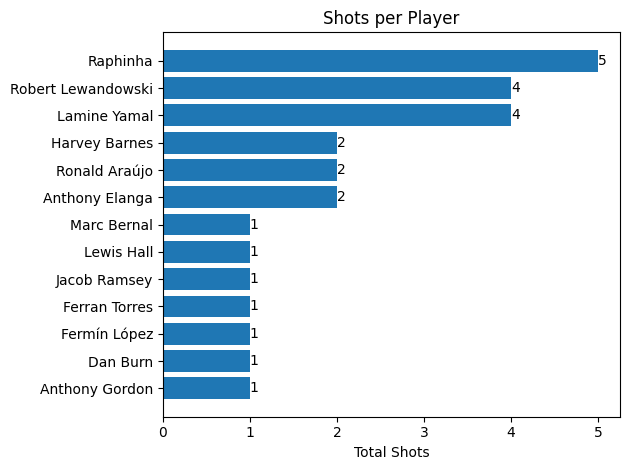

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Your data
data = {
    "player": [
        "Anthony Elanga","Anthony Gordon","Dan Burn","Fermín López",
        "Ferran Torres","Harvey Barnes","Jacob Ramsey","Lamine Yamal",
        "Lewis Hall","Marc Bernal","Raphinha","Robert Lewandowski","Ronald Araújo"
    ],
    "shots": [2,1,1,1,1,2,1,4,1,1,5,4,2]
}

df = pd.DataFrame(data)

# Sort values
df = df.sort_values(by="shots", ascending=True)

# Plot
plt.figure()
bars = plt.barh(df["player"], df["shots"])

# Add labels
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f"{int(width)}", va='center')

plt.xlabel("Total Shots")
plt.title("Shots per Player")
plt.tight_layout()
plt.show()

# Dangerous Shooters

In [13]:
shots_df.groupby("player")["xg"].sum().sort_values(ascending=False)

,xg
player,
Lamine Yamal,1.352007
Anthony Elanga,1.143657
Robert Lewandowski,0.889905
Raphinha,0.878707
Fermín López,0.603841
Marc Bernal,0.323339
Anthony Gordon,0.165768
Ferran Torres,0.137256
Ronald Araújo,0.100256


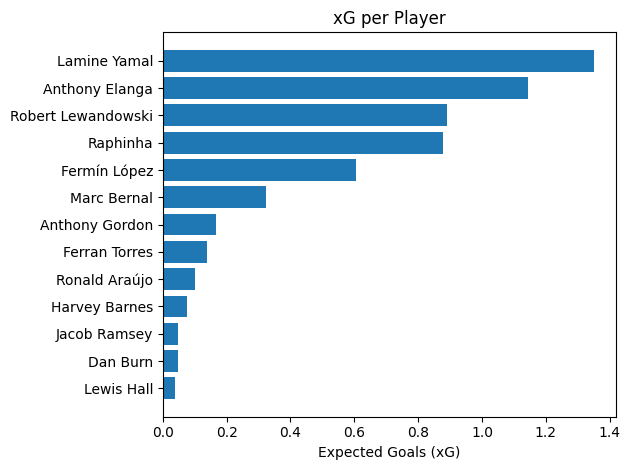

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Your data
data = {
    "player": [
        "Lamine Yamal","Anthony Elanga","Robert Lewandowski","Raphinha",
        "Fermín López","Marc Bernal","Anthony Gordon","Ferran Torres",
        "Ronald Araújo","Harvey Barnes","Jacob Ramsey","Dan Burn","Lewis Hall"
    ],
    "xg": [
        1.352007,1.143657,0.889905,0.878707,
        0.603841,0.323339,0.165768,0.137256,
        0.100256,0.075937,0.047727,0.046223,0.038754
    ]
}

df = pd.DataFrame(data)

# Sort values (important!)
df = df.sort_values(by="xg", ascending=True)

# Plot
plt.figure()
plt.barh(df["player"], df["xg"])
plt.xlabel("Expected Goals (xG)")
plt.title("xG per Player")
plt.tight_layout()
plt.show()

# Insight
While the home side dominated shot volume (18 vs 8), the away team proved more efficient in chance creation.
Lamine Yamal emerged as the most dangerous player (1.35 xG), consistently finding high-quality scoring opportunities.
However, Anthony Elanga’s 1.14 xG from just two shots highlights the away side’s effectiveness in generating high-value chances, likely through transitional play.

In contrast, Raphinha recorded the highest shot volume (5) but with lower overall efficiency, suggesting attempts from less optimal positions. Lewandowski maintained a strong central presence (0.89 xG), reflecting involvement in more dangerous areas.

Overall, the data suggests a contrast in styles: high-volume but lower-efficiency shooting from the home side versus a more clinical, chance-quality-focused approach from the away team.”

# Team total Expected goals (xG)

In [15]:
shots_df.groupby("team_home")["xg"].sum()

,xg
team_home,
False,1.518066
True,4.285311


# Insight
The match was characterized by clear attacking dominance from the home side, who outperformed the opposition in both shot volume (18 vs 8) and expected goals (4.29 vs 1.52).

Lamine Yamal emerged as the standout performer, generating 1.35 xG through consistent involvement in high-quality chances. The home attack was well-distributed, with contributions from Lewandowski (0.89 xG) and Raphinha (0.88 xG), reflecting a structured and sustained offensive approach.

In contrast, the away team relied on isolated opportunities, with Anthony Elanga producing 1.14 xG from just two shots, highlighting efficiency but a lack of consistent attacking presence.

Overall, the data suggests a contrast in attacking styles: a high-volume, high-quality approach from the home team versus a more reactive, transition-based strategy from the away side.”

# Separate the teams

In [24]:
home_shots = shots_df[shots_df["team_home"] == True]
away_shots = shots_df[shots_df["team_home"] == False]

# Comparing shot and Expected goal

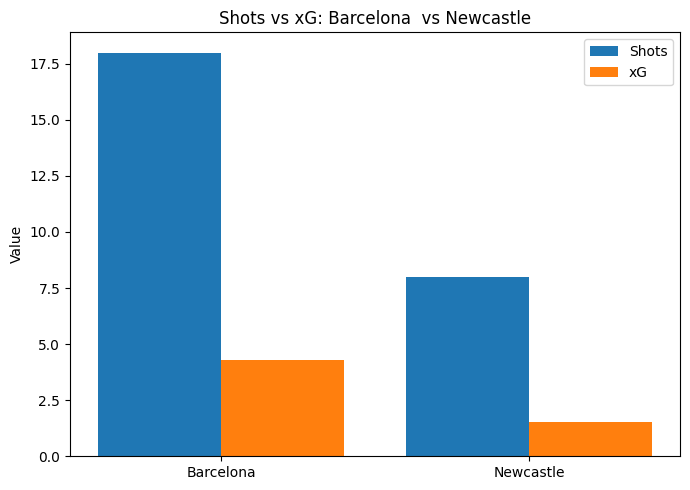

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Team": ["Barcelona", "Newcastle"],
    "Shots": [18, 8],
    "xG": [4.3, 1.51]
}

df = pd.DataFrame(data)

x = range(len(df))

plt.figure(figsize=(7,5))

plt.bar(x, df["Shots"], width=0.4, label="Shots")
plt.bar([i + 0.4 for i in x], df["xG"], width=0.4, label="xG")

plt.xticks([i + 0.2 for i in x], df["Team"])
plt.ylabel("Value")
plt.title("Shots vs xG: Barcelona  vs Newcastle")
plt.legend()

plt.tight_layout()
plt.show()

# number of situation per team

In [26]:
# Count shots per situation for each team
situation_counts = shots_df.groupby("team_home")["situation"].value_counts()
print(situation_counts)

team_home  situation         
False      assisted              4
           corner                2
           fast-break            1
           throw-in-set-piece    1
True       assisted              9
           corner                3
           fast-break            2
           regular               2
           penalty               1
           set-piece             1
Name: count, dtype: int64


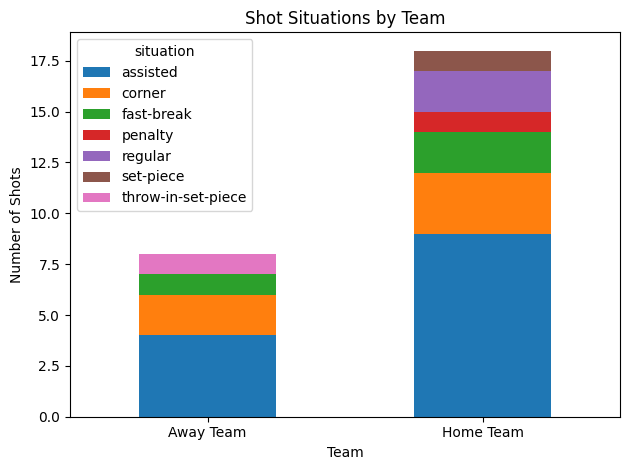

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "team_home": ["False","False","False","False","True","True","True","True","True","True"],
    "situation": [
        "assisted","corner","fast-break","throw-in-set-piece",
        "assisted","corner","fast-break","regular","penalty","set-piece"
    ],
    "shots": [4,2,1,1,9,3,2,2,1,1]
}

df = pd.DataFrame(data)
pivot = df.pivot(index="team_home", columns="situation", values="shots").fillna(0)

pivot.plot(kind="bar", stacked=True)

plt.xlabel("Team")
plt.ylabel("Number of Shots")
plt.title("Shot Situations by Team")
plt.xticks(ticks=[0,1], labels=['Away Team','Home Team'], rotation=0)
plt.tight_layout()
plt.show()

# number of situation per team and player

In [28]:
# Count number of shots per player per situation, keeping team info
situation_counts = shots_df.groupby(["team_home", "player"])["situation"].value_counts().reset_index(name="shots")
print(situation_counts)

    team_home              player           situation  shots
0       False      Anthony Elanga            assisted      2
1       False      Anthony Gordon            assisted      1
2       False            Dan Burn              corner      1
3       False       Harvey Barnes              corner      1
4       False       Harvey Barnes          fast-break      1
5       False        Jacob Ramsey  throw-in-set-piece      1
6       False          Lewis Hall            assisted      1
7        True        Fermín López            assisted      1
8        True       Ferran Torres            assisted      1
9        True        Lamine Yamal            assisted      2
10       True        Lamine Yamal          fast-break      1
11       True        Lamine Yamal             penalty      1
12       True         Marc Bernal           set-piece      1
13       True            Raphinha            assisted      2
14       True            Raphinha             regular      2
15       True           

In [21]:
situation_counts.head()

,team_home,player,situation,shots
0,False,Anthony Elanga,assisted,2
1,False,Anthony Gordon,assisted,1
2,False,Dan Burn,corner,1
3,False,Harvey Barnes,corner,1
4,False,Harvey Barnes,fast-break,1


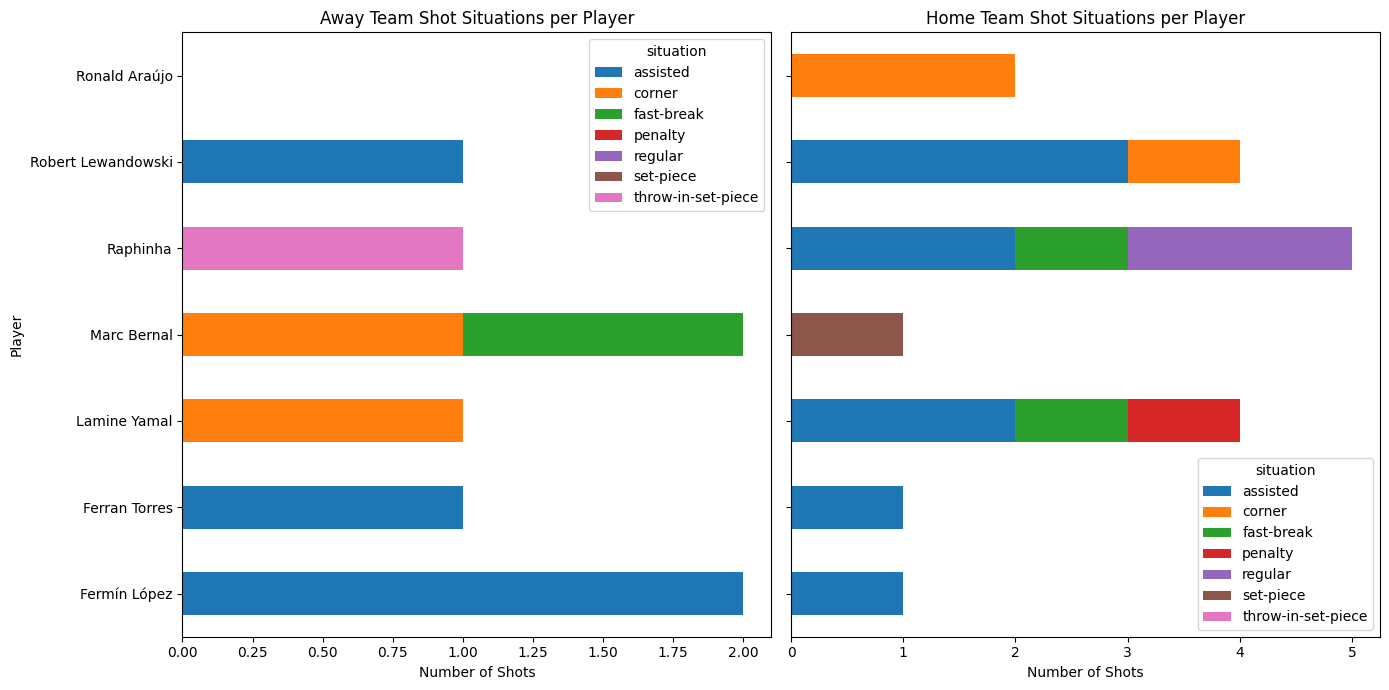

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Your data
data = {
    "team_home": [
        False, False, False, False, False, False, False,
        True, True, True, True, True, True, True, True, True, True, True, True
    ],
    "player": [
        "Anthony Elanga","Anthony Gordon","Dan Burn","Harvey Barnes","Harvey Barnes",
        "Jacob Ramsey","Lewis Hall","Fermín López","Ferran Torres","Lamine Yamal",
        "Lamine Yamal","Lamine Yamal","Marc Bernal","Raphinha","Raphinha","Raphinha",
        "Robert Lewandowski","Robert Lewandowski","Ronald Araújo"
    ],
    "situation": [
        "assisted","assisted","corner","corner","fast-break","throw-in-set-piece","assisted",
        "assisted","assisted","assisted","fast-break","penalty","set-piece",
        "assisted","regular","fast-break","assisted","corner","corner"
    ],
    "shots": [
        2,1,1,1,1,1,1,1,1,2,1,1,1,2,2,1,3,1,2
    ]
}

df = pd.DataFrame(data)

# Pivot for stacked bar chart
pivot = df.pivot_table(
    index=["team_home","player"],
    columns="situation",
    values="shots",
    fill_value=0
)

# Separate Home and Away Teams
away_shots= pivot.loc[True]
home_shots = pivot.loc[False]

# Plotting
fig, axes = plt.subplots(1,2, figsize=(14,7), sharey=True)

# Home team
home_shots.plot(kind="barh", stacked=True, ax=axes[0])
axes[0].set_title("Away Team Shot Situations per Player")
axes[0].set_xlabel("Number of Shots")
axes[0].set_ylabel("Player")

# Away team
away_shots.plot(kind="barh", stacked=True, ax=axes[1])
axes[1].set_title("Home Team Shot Situations per Player")
axes[1].set_xlabel("Number of Shots")

plt.tight_layout()
plt.show()

# Insight
This match analysis shows a clear contrast in attacking approaches. The home team created a well-distributed variety of shots with dominance in build-up play. The away team focused on high-value, situational chances, mainly through transitions and set-pieces. Player contributions highlight key performers: Lamine Yamal and Lewandowski for home dominance, Elanga for away efficiency.”

# shot type per team

In [ ]:
shot_type_counts = shots_df.groupby("team_home")["shot_type"].value_counts()
print(shot_type_counts)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Your data
data = {
    "team_home": [False, False, False, False, True, True, True, True],
    "shot_type": ["save","goal","miss","block","goal","save","block","miss"],
    "shots": [3,2,2,1,7,6,3,2]
}

df = pd.DataFrame(data)

# Pivot table using correct column
pivot_df = df.pivot(index='team_home', columns='shot_type', values='shots').fillna(0)

print(pivot_df)

# Insight
# Home Team (True)

Key players: Robert Lewandowski, Lamine Yamal, Raphinha

Shot situations (from stacked bar chart):

Mostly assisted shots

Raphinha contributes from regular play and fast-breaks

Minimal set-piece involvement (Marc Bernal → 1 shot, Lamine Yamal → penalty)

Shot outcomes:

Goals: 7

Saves: 6

Blocks: 3

Misses: 2

Interpretation:

“The home team dominates possession and creates structured attacking opportunities. Lewandowski and Yamal are the main finishers from build-up play, while Raphinha adds unpredictability with fast-break and open-play shots. The team is highly efficient in converting chances, but the opposition still made key saves.”

# Away Team (False)

Key players: Anthony Elanga, Harvey Barnes

Shot situations:

Mainly assisted shots

Some corners and fast-breaks

Limited set-piece or regular play contribution

Shot outcomes:

Goals: 2

Saves: 3

Blocks: 1

Misses: 2

Interpretation:

“The away team is more reactive, relying on transitions and selective chances. Anthony Elanga is the main threat, mostly in assisted situations. Efficiency is lower — many shots are saved or blocked. The team’s attack is opportunistic rather than sustained.”

📊 Player-Level Insights

Lamine Yamal: Versatile attacker, threats from assisted and fast-break situations → very dynamic

Robert Lewandowski: Central finisher, mostly assisted shots → focal point of structured attacks

Raphinha: Mixed contributions (assisted, regular, fast-break) → adds unpredictability

Anthony Elanga: Efficient with limited chances → strong in transitions

Defenders: Ronald Araújo & Dan Burn → mostly contributing via corners → aerial threat

📊 Tactical Takeaways

Home team: Controlled possession, varied shot situations, high conversion → strong structured attack

Away team: Low volume, situational shots, selective transitions → reactive but potentially dangerous on counters

Efficiency difference: Home team better at creating and finishing chances; away team relies on opportunistic shots

# Shots by body part

In [ ]:
shots_df["body_part"].value_counts()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
data = {
    "body_part": ["right-foot", "left-foot", "head"],
    "count": [16, 6, 4]
}

df = pd.DataFrame(data)

# Sort if needed
df = df.sort_values(by="count", ascending=True)

# Plot
plt.figure(figsize=(6,4))
bars = plt.barh(df["body_part"], df["count"], color="skyblue")

# Add labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.3, bar.get_y() + bar.get_height()/2,
             str(int(width)), va='center', fontsize=10, fontweight='bold')

plt.xlabel("Number of Shots")
plt.title("Shots by Body Part")
plt.tight_layout()
plt.show()

# Plot shot map

In [ ]:
plt.scatter(shots_df["x"], shots_df["y"], c=shots_df["xg"], s=shots_df["xg"]*500, cmap="Reds")
plt.xlabel("Distance from goal")
plt.ylabel("Pitch width")
plt.title("Shot Map")
plt.show()

In [ ]:
home = shots_df[shots_df["team_home"] == True]
away = shots_df[shots_df["team_home"] == False]

#Plot the home team shots

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(
    home["x"],
    home["y"],
    s=home["xg"]*500,
    c="blue",
    edgecolor="blue",
    alpha=0.7,
    label="Away Team"
)

# Plot the away team shots

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(
    away["x"],
    away["y"],
    s=away["xg"]*500,
    c="black",
    edgecolor="black",
    alpha=0.7,
    label="Away Team"
)

In [ ]:
!pip install mplsoccer

# Both teams shots map

In [ ]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

pitch = Pitch(pitch_type='statsbomb', pitch_color='green', line_color='white')

fig, ax = pitch.draw(figsize=(8,6))

pitch.scatter(
    shots_df["x"],
    shots_df["y"],
    s=shots_df["xg"]*600,
    c=shots_df["xg"],
    cmap="Reds",
    edgecolors="black",
    ax=ax
)

plt.title("Both Teams Shot Map")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(10,6))

home = shots_df[shots_df["team_home"] == True]
away = shots_df[shots_df["team_home"] == False]

plt.scatter(home["x"], home["y"], s=home["xg"]*500,
            c="red", edgecolor="black", alpha=0.7, label="Home")

plt.scatter(away["x"], away["y"], s=away["xg"]*500,
            c="black", edgecolor="black", alpha=0.7, label="Away")

plt.title("Shot Map Comparison")
plt.xlabel("Pitch Length")
plt.ylabel("Pitch Width")
plt.legend()

plt.show()

# Home Team shots map

In [ ]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

pitch = Pitch(pitch_type='statsbomb', pitch_color='green', line_color='white')

fig, ax = pitch.draw(figsize=(8,6))

pitch.scatter(
    home["x"],
    home["y"],
    s=home["xg"]*600,
    c=home["xg"],
    cmap="Reds",
    edgecolors="black",
    ax=ax
)

plt.title("Home Team Shot Map")
plt.legend()
plt.show()

# What This Shot Map Shows
🟢 1. Shot Location

Almost all shots are concentrated inside the penalty box

Very few long-range attempts

👉 This means:

The home team is creating high-quality chances, not just shooting from distance

🔴 2. Shot Quality (xG)

Bigger red circles = higher xG (better chances)

You have multiple large circles close to goal

👉 Interpretation:

The team created several big chances in dangerous areas

🎯 3. Central vs Wide Areas

Most shots are from the left side of the box

Very few from:

Right side

Outside the box

👉 This suggests:

The attack is left-side dominant (could be winger/fullback influence)

🧠 4. Finishing Zones

Many shots are:

Near the 6-yard box

Around the penalty spot

👉 These are:

The highest probability scoring areas on the pitch

⚠️ 5. Shot Spread

Tight cluster of shots → sustained attacking pressure

Not scattered → not random shooting

👉 Meaning:

The team had control in the final third

📊 What You Can Conclude
🔥 Strong Points

High-quality chance creation (good xG positions)

Consistent penetration into the box

Structured attacking play

⚠️ Possible Weakness

Heavy reliance on left side

Could be predictable against stronger defenses

# Away Team shots map

In [ ]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

pitch = Pitch(pitch_type='statsbomb', pitch_color='green', line_color='white')

fig, ax = pitch.draw(figsize=(8,6))

pitch.scatter(
    away["x"],
    away["y"],
    s=away["xg"]*600,
    c=away["xg"],
    cmap="Blues",
    edgecolors="black",
    ax=ax
)

plt.title("Away Team Shot Map")
plt.legend()
plt.show()

# Away Team Shot Map – Breakdown
🔵 1. Shot Volume

Very few shots overall compared to the home team

Sparse distribution

👉 Interpretation:

The away team created limited attacking opportunities

📍 2. Shot Locations

Most shots are still inside the box

But fewer central, high-danger positions

Some shots slightly wider or deeper

👉 Meaning:

They reached the box, but not as consistently or dangerously

🔴 3. Shot Quality (xG)

Fewer large circles (high xG chances)

Most shots appear small → low probability

👉 Interpretation:

The away team struggled to create clear-cut chances

🧠 4. Attacking Pattern

No strong clustering like the home team

Less pressure in dangerous zones

👉 Meaning:

More opportunistic or isolated attacks, not sustained pressure

🔥 Now the KEY: Home vs Away Comparison
🏠 Home Team

Many shots

High xG chances

Strong clustering in the box

Left-side dominance

Sustained attacking pressure

✈️ Away Team

Few shots

Lower xG

Less central penetration

Scattered attempts

Reactive attacking

# Match Story
“The home team dominated attacking play, generating a higher volume of shots and consistently creating high-quality chances in central areas. In contrast, the away team produced fewer opportunities with lower overall shot quality, relying on sporadic attacks rather than sustained pressure.”

# Conclusion:
The home team delivered a dominant attacking performance, combining high shot volume with high-quality chances. Their structured and varied attacking approach allowed multiple players to contribute effectively. In contrast, the away team struggled to generate consistent pressure, relying on isolated moments and producing fewer dangerous opportunities.

# Recommendations:

• Home team: Maintain strong central attacking patterns but improve variation by involving the right side more, while also focusing on converting high-quality chances more efficiently.

• Away team: Improve both shot volume and quality by developing more structured build-up play and reducing reliance on individual moments. Creating more central chances will be key to increasing goal threat.